<a href="https://colab.research.google.com/github/GaneshSparkz/Drowsiness-Detection-System-CNN-OpenCV/blob/main/DrowsinessDetectorTraining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import required Libraries

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPool2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Activation
from tensorflow.keras.utils import plot_model

Load the Preprocessed Dataset

In [14]:
X_train = np.load("data/X_train.npy")
y_train = np.load("data/y_train.npy")

X_test = np.load("data/X_test.npy")
y_test = np.load("data/y_test.npy")



Hyperparameters and Data Augmentation

In [15]:
# Hyperparameters
LEARNING_RATE = 1e-3
EPOCHS = 15
BATCH_SIZE = 16

In [16]:
# Data Augmentation
data_gen = ImageDataGenerator(
    width_shift_range=0.1,
    height_shift_range=0.1,
    rotation_range=10,
    shear_range=0.1,
    zoom_range=0.2
)
data_gen.fit(X_train)

Build the Model

In [17]:
model = Sequential()
# first CNN layer
model.add(Conv2D(32, (3, 3), input_shape=(24, 24, 1)))
model.add(Activation('relu'))
model.add(MaxPool2D((1, 1)))
# second CNN layer
model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPool2D((1, 1)))
# third CNN layer
model.add(Conv2D(64, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPool2D((1, 1)))
model.add(Dropout(0.25))
# FC -> relu layer
model.add(Flatten())
model.add(Dense(128))
model.add(Activation('relu'))
model.add(Dropout(0.5))
# final layer -> sigmoid classification
model.add(Dense(1))
model.add(Activation('sigmoid'))

Compile and Visualize the model

In [18]:
model.compile(
    optimizer=RMSprop(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
try:
    plot_model(model, to_file="model.png", show_shapes=True)
except Exception as e:
    print("Skipping plot_model: Graphviz/pydot may be missing or misconfigured:", e)
model.summary()

Skipping plot_model: Graphviz/pydot may be missing or misconfigured: module 'pydot' has no attribute 'InvocationException'


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 22, 22, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 20, 20, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 20, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 20, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 18, 18, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,682,529 (10.23 MB)

 Trainable params: 2,682,529 (10.23 MB)

 Non-trainable params: 0 (0.00 B)

Train the model

In [19]:
history = model.fit(
    data_gen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    shuffle=True,
)

Epoch 1/15


C:\Users\imlou\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


78/78 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.6049 - loss: 0.6644 - val_accuracy: 0.9266 - val_loss: 0.2615
Epoch 2/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.7727 - loss: 0.4763 - val_accuracy: 0.9450 - val_loss: 0.1680
Epoch 3/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.8660 - loss: 0.3623 - val_accuracy: 0.9495 - val_loss: 0.2326
Epoch 4/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.9067 - loss: 0.2738 - val_accuracy: 0.9495 - val_loss: 0.1436
Epoch 5/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.8947 - loss: 0.2327 - val_accuracy: 0.9541 - val_loss: 0.1255
Epoch 6/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.9316 - loss: 0.2112 - val_accuracy: 0.9495 - val_loss: 0.1149
Epoch 7/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.9406 - loss: 0.1842 - val_accuracy: 0.9541 - val_loss: 0.0986
Epoch 8/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.9346 - loss: 0.1548 - val_accuracy: 0.9587 - val_loss: 0.

Plot the Results

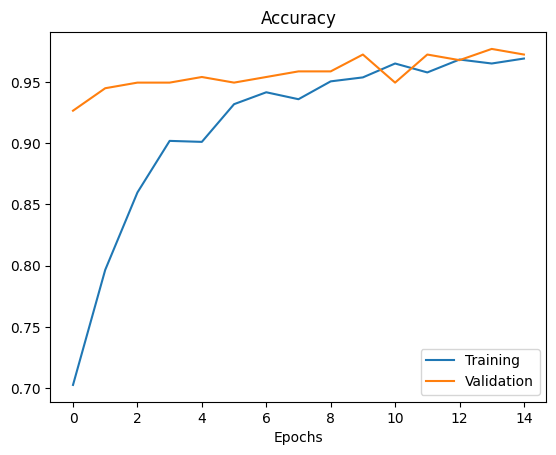

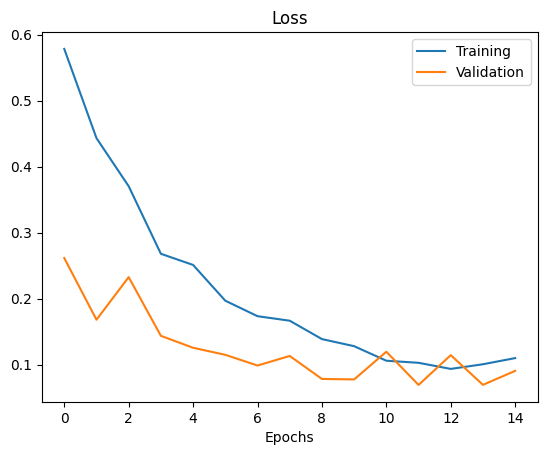

In [20]:
plt.figure(1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Training', 'Validation'])
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.figure(2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Training', 'Validation'])
plt.title('Loss')
plt.xlabel('Epochs')
plt.show()

Save the trained model

In [21]:
model.save("trained_model.h5")